# Evaluation Metrics Project

A model can look accurate and still completely fail in the real world.

That sentence is the heart of this project.

Evaluation metrics are not a formula checklist. They are the science of knowing whether your model is actually useful. They tell us what kind of mistakes the model makes, who pays for those mistakes, and whether the model is safe enough to guide decisions.

> A model can look accurate and still completely fail in the real world.

## 1. Problem Statement

Evaluating ML models is difficult because a score is never just a score.

In cancer detection, a false negative can mean a missed diagnosis. In fraud detection, a false negative can mean money lost. In spam filtering, a false positive can mean an important email disappears.

Accuracy treats all mistakes as equal. Real life does not.

This project uses customer churn prediction to show how metrics become business decisions. If we wrongly flag a loyal customer as churn risk, we may waste retention budget. If we miss a customer who is actually about to leave, we may lose revenue.

The question is not simply: how accurate is the model?

The real question is:

> Is the model making the right kind of mistakes for this business problem?

## 2. The Accuracy Trap

Imagine a fraud dataset where 99% of transactions are legitimate and 1% are fraud.

A model that predicts `not fraud` for every transaction gets 99% accuracy.

It also catches zero fraud.

That is the accuracy trap: a model can look successful by ignoring the rare event we care about most.

Accuracy asks, "How often was the model right?"

But in imbalanced problems, we also need to ask:

- What did the model miss?
- What did the model falsely accuse?
- Which mistake is more expensive?
- Which mistake is more dangerous?

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd

fraud_y_true = np.array([0] * 990 + [1] * 10)
fraud_y_pred = np.zeros_like(fraud_y_true)
accuracy_trap = pd.DataFrame([
    {
        "scenario": "Predict non-fraud for everyone",
        "accuracy": accuracy_score(fraud_y_true, fraud_y_pred),
        "precision": precision_score(fraud_y_true, fraud_y_pred, zero_division=0),
        "recall": recall_score(fraud_y_true, fraud_y_pred, zero_division=0),
        "f1": f1_score(fraud_y_true, fraud_y_pred, zero_division=0),
        "fraud_cases_caught": int(((fraud_y_true == 1) & (fraud_y_pred == 1)).sum()),
    }
])
accuracy_trap

,scenario,accuracy,precision,recall,f1,fraud_cases_caught
0,Predict non-fraud for everyone,0.99,0.0,0.0,0.0,0


## 3. Dataset Overview

Dataset: IBM Telco Customer Churn Dataset.

Rows: 7,043 customers

Target variable: `churn`

Business interpretation:

- `1`: customer churned
- `0`: customer stayed

False positives: loyal customers incorrectly flagged as churn risks. This can waste discounts, outreach time, or retention budget.

False negatives: churn-risk customers missed by the model. This can lead to preventable customer loss.

Both mistakes matter, but they do not cost the same.

## 4. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from src.preprocessing.data_preprocessing import TARGET_COLUMN, save_processed, split_features_target
from src.experiments.model_experiments import logistic_model, random_forest_model
from src.metrics.classification_metrics import metrics_at_threshold, threshold_table
from src.thresholding.threshold_tuning import tune_thresholds
from src.evaluation.reports import text_classification_report
from src.visualization.plots import (
    plot_confusion_matrix,
    plot_metric_bars,
    plot_precision_recall_tradeoff,
    plot_roc_curve,
    plot_pr_curve,
    plot_business_cost,
)

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 5. Load Dataset

In [3]:
raw_path = PROJECT_ROOT / "data/raw/telco_customer_churn.csv"
processed_path = PROJECT_ROOT / "data/processed/telco_customer_churn_processed.csv"

df = save_processed(raw_path, processed_path)
df.head()

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 6. Initial Data Inspection

In [4]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(8))
print("\nClass distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("proportion"))
df.info()

Shape: (7043, 20)

Missing values:
totalcharges        11
gender               0
seniorcitizen        0
monthlycharges       0
paymentmethod        0
paperlessbilling     0
contract             0
streamingmovies      0
dtype: int64

Class distribution:
0    0.73463
1    0.26537
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   seniorcitizen     7043 non-null   int64  
 2   partner           7043 non-null   object 
 3   dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   phoneservice      7043 non-null   object 
 6   multiplelines     7043 non-null   object 
 7   internetservice   7043 non-null   object 
 8   onlinesecurity    7043 non-null   object 
 9   onlinebackup      7043 non-null   object 
 10  deviceprotec

## 7. Exploratory Data Analysis

The target is imbalanced: more customers stay than leave. That does not make accuracy useless, but it means accuracy cannot be the only judge.

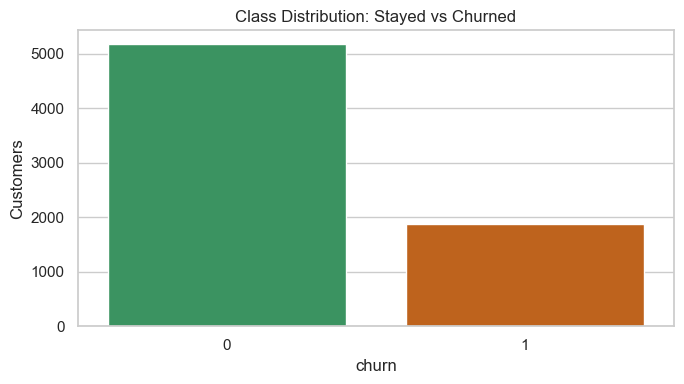

In [5]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=TARGET_COLUMN, palette=["#2ca25f", "#d95f02"])
plt.title("Class Distribution: Stayed vs Churned")
plt.xlabel("churn")
plt.ylabel("Customers")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "class_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

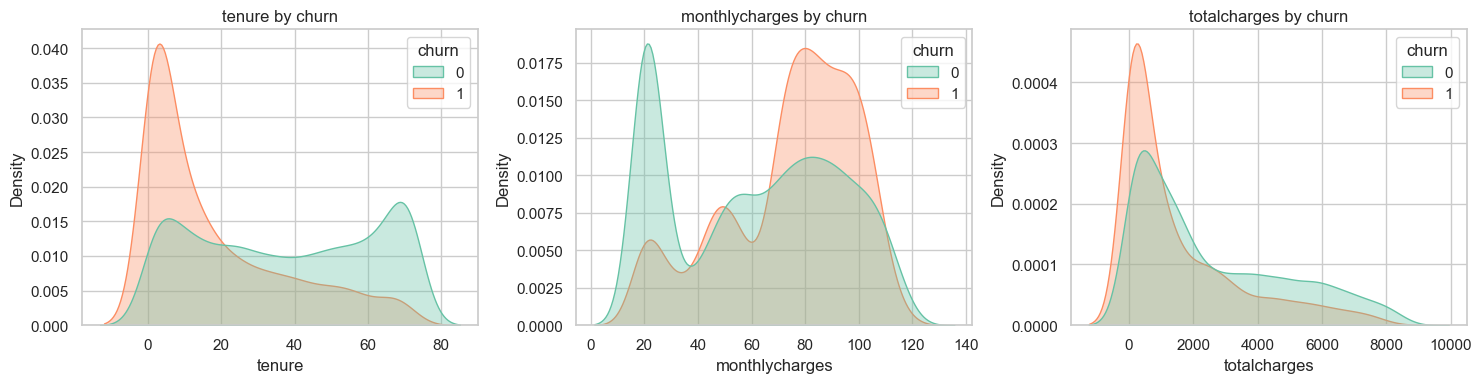

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "monthlycharges", "totalcharges"]):
    sns.kdeplot(data=df, x=col, hue=TARGET_COLUMN, fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_relationships.png", dpi=160, bbox_inches="tight")
plt.show()

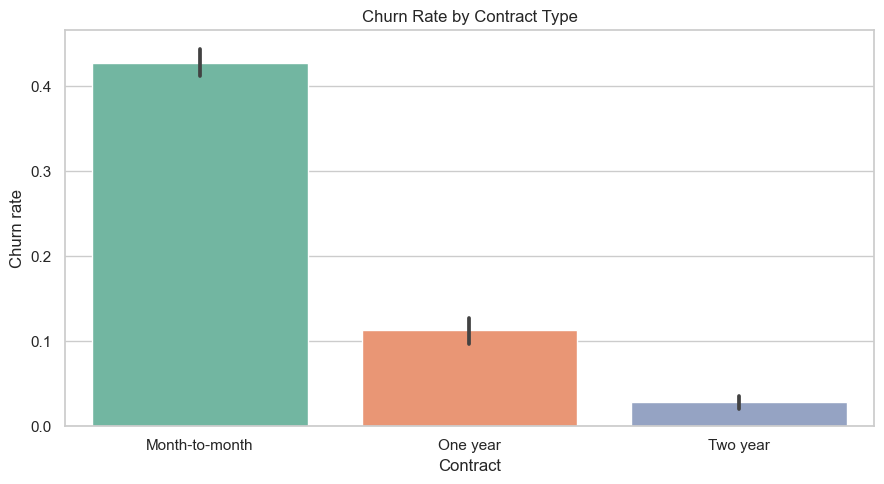

In [7]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="contract", y=TARGET_COLUMN, estimator=np.mean, palette="Set2")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "contract_churn_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Build Baseline Model

We train Logistic Regression because it gives probabilities. Metrics such as ROC-AUC, PR curves, and threshold tuning depend on probability scores, not just hard class labels.

In [8]:
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

model = logistic_model(X)
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

baseline_metrics = pd.DataFrame([metrics_at_threshold(y_test, y_proba, 0.5)])
baseline_metrics.round(4)

,threshold,accuracy,precision,recall,f1,roc_auc,predicted_positive_rate
0,0.5,0.7501,0.5188,0.7966,0.6284,0.846,0.4072


## 9. Understanding the Confusion Matrix

The confusion matrix is where model evaluation becomes human.

It shows the four possible outcomes:

- True Negative: predicted stayed, actually stayed
- True Positive: predicted churned, actually churned
- False Positive: predicted churned, actually stayed
- False Negative: predicted stayed, actually churned

In medical diagnosis, false negatives can be devastating because a disease is missed. In spam filtering, false positives can be painful because important emails are hidden. In churn, false negatives mean missed customers who may leave.

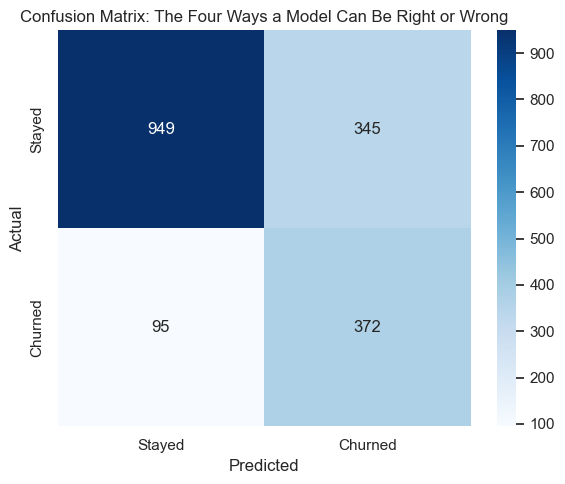

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1294
           1       0.52      0.80      0.63       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.81      0.75      0.76      1761



In [9]:
plot_confusion_matrix(y_test, y_pred_05, IMAGES_DIR / "confusion_matrix.png", labels=("Stayed", "Churned"))
plt.show()
print(text_classification_report(y_test, y_pred_05))

## 10. Accuracy Explained Intuitively

Accuracy is the percentage of all predictions the model got right.

It works best when classes are balanced and mistake costs are similar.

It fails when one class dominates or when one kind of mistake is much more expensive than another.

In [10]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
comparison = pd.DataFrame([
    {"model": "Predict stayed for everyone", "accuracy": accuracy_score(y_test, dummy_pred), "precision": precision_score(y_test, dummy_pred, zero_division=0), "recall": recall_score(y_test, dummy_pred, zero_division=0), "f1": f1_score(y_test, dummy_pred, zero_division=0)},
    {"model": "Logistic Regression", "accuracy": accuracy_score(y_test, y_pred_05), "precision": precision_score(y_test, y_pred_05), "recall": recall_score(y_test, y_pred_05), "f1": f1_score(y_test, y_pred_05)},
])
comparison.round(4)

,model,accuracy,precision,recall,f1
0,Predict stayed for everyone,0.7348,0.0000,0.0000,0.0000
1,Logistic Regression,0.7501,0.5188,0.7966,0.6284


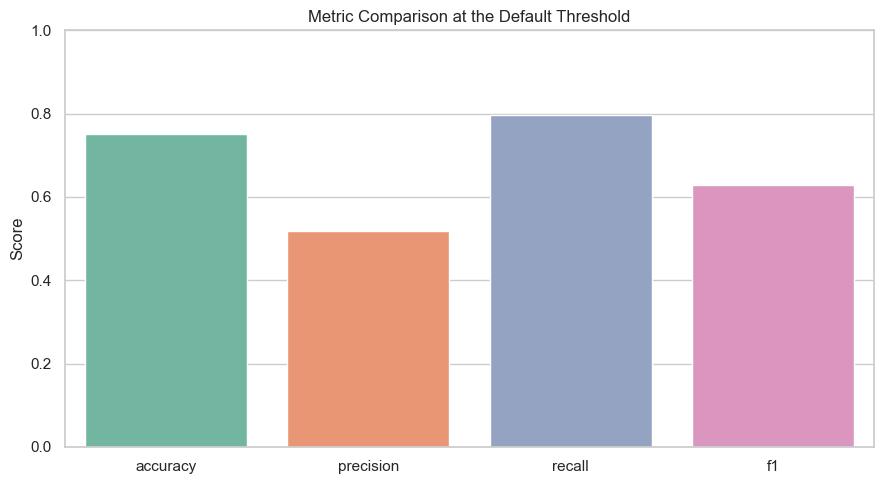

In [11]:
plot_metric_bars(baseline_metrics, IMAGES_DIR / "metric_comparison.png")
plt.show()

## 11. Precision Explained Intuitively

Precision asks:

> When the model says churn risk, how often is it right?

Precision matters when false positives are expensive. In spam filtering, high precision means emails flagged as spam are usually spam. In churn, high precision means retention teams are not wasting too much effort on customers who were likely to stay.

## 12. Recall Explained Intuitively

Recall asks:

> Of all customers who actually churned, how many did the model catch?

Recall matters when false negatives are expensive. In cancer detection, missing a positive case can be life-changing. In fraud detection, missing fraud can mean direct financial loss. In churn, missing at-risk customers means losing customers we might have saved.

Recall is emotionally important because it measures what slipped through the net.

## 13. Precision vs Recall Tradeoff

Precision and recall often pull against each other.

If we lower the threshold, the model flags more customers as churn risks. Recall usually rises because we catch more churners, but precision may fall because we also flag more loyal customers.

If we raise the threshold, the model becomes more cautious. Precision may rise, but recall may fall.

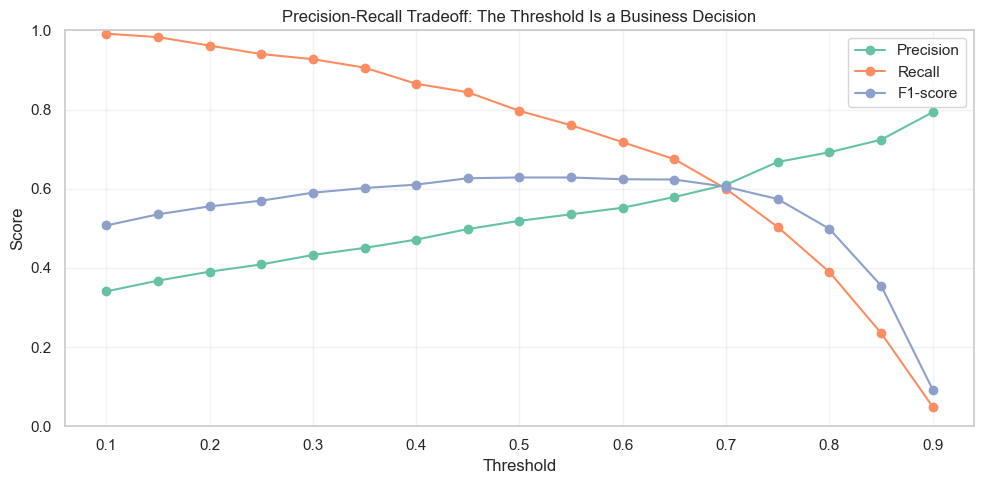

,threshold,accuracy,precision,recall,f1,roc_auc,predicted_positive_rate,false_positives,false_negatives,estimated_cost
0,0.10,0.4889,0.3407,0.9914,0.5071,0.846,0.7717,896,4,23200
1,0.15,0.5474,0.3678,0.9829,0.5353,0.846,0.7087,789,8,21325
2,0.20,0.5917,0.3904,0.9615,0.5553,0.846,0.6530,701,18,21125
3,0.25,0.6235,0.4088,0.9400,0.5698,0.846,0.6099,635,28,21475
4,0.30,0.6581,0.4326,0.9272,0.5899,0.846,0.5684,568,34,21000


In [12]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_df = tune_thresholds(y_test.reset_index(drop=True), y_proba, thresholds, fp_cost=25, fn_cost=200)
plot_precision_recall_tradeoff(threshold_df, IMAGES_DIR / "precision_recall_tradeoff.png")
plt.show()
threshold_df.round(4).head()

## 14. F1-Score Explained Intuitively

F1-score balances precision and recall.

It uses the harmonic mean, which punishes imbalance. A model cannot get a strong F1-score by having excellent precision and terrible recall, or excellent recall and terrible precision.

F1 is useful when we care about both false positives and false negatives and want one compact balance score.

## 15. ROC Curve and AUC

The ROC curve shows how recall, also called true positive rate, changes against false positive rate across thresholds.

AUC measures ranking ability: if we randomly choose one churned customer and one non-churned customer, how often does the model rank the churned customer as higher risk?

ROC-AUC is useful for measuring separation, but it can look optimistic when classes are highly imbalanced.

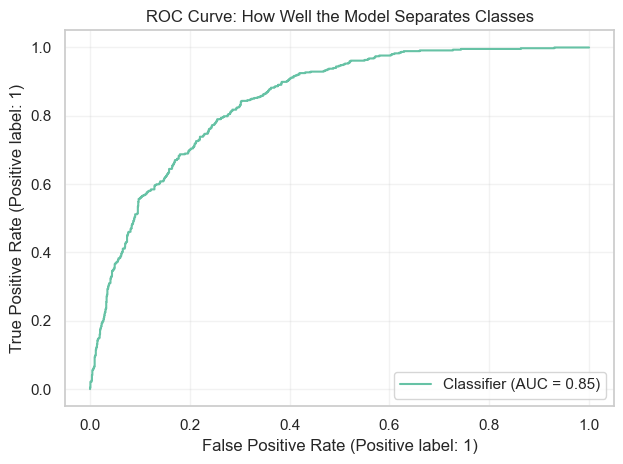

ROC-AUC: 0.846


In [13]:
plot_roc_curve(y_test, y_proba, IMAGES_DIR / "roc_curve.png")
plt.show()
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))

## 16. Precision-Recall Curve

Precision-Recall curves are often more honest for imbalanced datasets.

They focus on performance for the positive class. In churn, that means the customers who actually leave. When the positive class is rare, PR curves often reveal tradeoffs that ROC curves can smooth over.

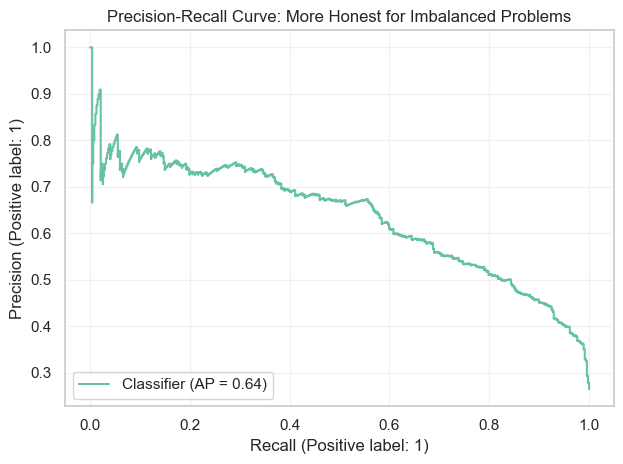

Average precision: 0.6357


In [14]:
plot_pr_curve(y_test, y_proba, IMAGES_DIR / "precision_recall_curve.png")
plt.show()
print("Average precision:", round(average_precision_score(y_test, y_proba), 4))

## 17. Threshold Tuning

The default threshold of 0.5 is not sacred.

Threshold tuning is where evaluation becomes operational. A business may prefer catching more churners even if it means more false alerts. Another business may have limited retention budget and want fewer, higher-confidence outreach targets.

In [15]:
selected_thresholds = threshold_df.loc[threshold_df["threshold"].isin([0.25, 0.4, 0.5, 0.65, 0.8])]
selected_thresholds[["threshold", "accuracy", "precision", "recall", "f1", "false_positives", "false_negatives", "estimated_cost"]].round(4)

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,estimated_cost
3,0.25,0.6235,0.4088,0.9400,0.5698,635,28,21475
6,0.40,0.7070,0.4714,0.8651,0.6103,453,63,23925
8,0.50,0.7501,0.5188,0.7966,0.6284,345,95,27625
11,0.65,0.7836,0.5790,0.6745,0.6231,229,152,36125
14,0.80,0.7922,0.6920,0.3897,0.4986,81,285,59025


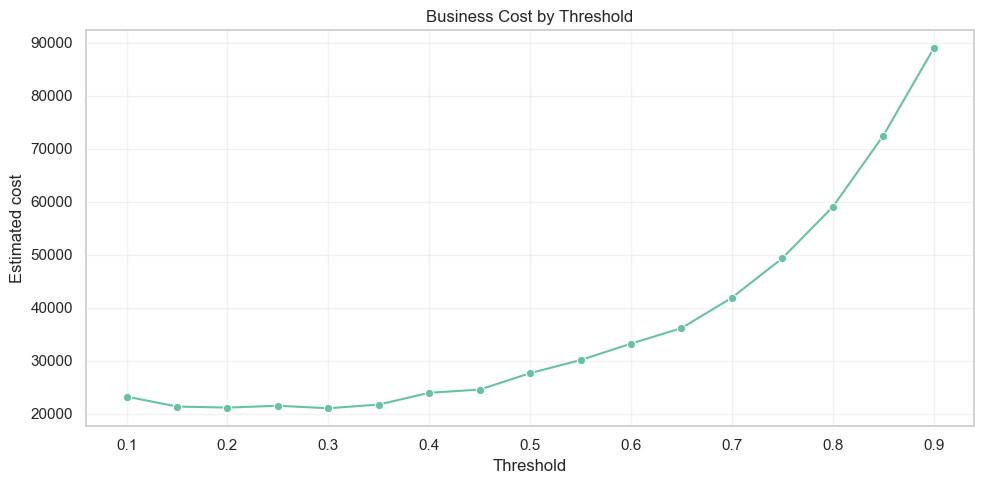

Best cost threshold: 0.3
Best F1 threshold: 0.5


In [16]:
plot_business_cost(threshold_df, IMAGES_DIR / "threshold_business_cost.png")
plt.show()
best_cost_row = threshold_df.loc[threshold_df["estimated_cost"].idxmin()]
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print("Best cost threshold:", round(best_cost_row["threshold"], 2))
print("Best F1 threshold:", round(best_f1_row["threshold"], 2))

## 18. Regression Metrics Mini Section

Classification metrics are not the whole evaluation world.

For regression, we measure how far predictions are from continuous values.

- MAE: average absolute error, easy to explain
- MSE: squared error, punishes large mistakes strongly
- RMSE: square root of MSE, in original target units
- R2: how much variance the model explains compared with a baseline

If predicting house prices, MAE says the typical dollar error. RMSE gets angry about very large pricing mistakes.

In [17]:
actual = np.array([200, 250, 310, 400, 520])
predicted = np.array([210, 230, 330, 360, 590])
regression_metrics = pd.DataFrame([
    {
        "MAE": mean_absolute_error(actual, predicted),
        "MSE": mean_squared_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted, squared=False),
        "R2": r2_score(actual, predicted),
    }
])
regression_metrics.round(3)

,MAE,MSE,RMSE,R2
0,32.0,1480.0,38.471,0.885


## 19. Choosing the Right Metric

The right metric depends on the decision.

Fraud detection often prioritizes recall because missed fraud is expensive. Spam filtering often prioritizes precision because hiding real emails hurts trust. Medical screening often emphasizes recall because missing a disease can be dangerous. Recommendation systems may use ranking metrics because the order of suggestions matters. Regression problems may use MAE or RMSE depending on whether large errors deserve extra punishment.

A metric is not just math. It is a statement about what kind of mistake the business can tolerate.

## 20. Practical ML Evaluation Workflow

A practical evaluation workflow looks like this:

1. Understand the business cost of false positives and false negatives.
2. Choose metrics before chasing model scores.
3. Split data carefully and avoid leakage.
4. Use cross-validation for robust estimates.
5. Evaluate probability quality, not only class labels.
6. Tune thresholds on validation data.
7. Keep a final test set for honest evaluation.
8. Monitor metrics in production because class balance and customer behavior can change.

## 21. Final Takeaway

Evaluation metrics exist because accuracy alone does not know what your business cares about.

A model can be accurate and useless. A model can have lower accuracy but save more customers, catch more fraud, or reduce more harm.

The real skill is not memorizing metric formulas.

The real skill is knowing which mistakes matter.

## 22. Interview Questions

For detailed interview preparation, see:

`evaluation-metrics/interview_questions.md`

The companion interview article explains these ideas in practical ML engineering language.